# Chapter 8: Numerical Methods

This notebook covers numerical stability in machine learning training:

1. Floating Point Representation
2. Catastrophic Cancellation
3. The Log-Sum-Exp Trick
4. Numerically Stable Cross-Entropy
5. Gradient Checking
6. Mixed Precision Training
7. Debugging NaN and Inf

Understanding numerical stability is crucial for training deep neural networks. Small numerical errors can accumulate and cause training to fail with NaN losses or exploding gradients.

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact
import warnings

# Configure matplotlib
plt.rcParams['figure.figsize'] = [12, 6]
plt.rcParams['font.size'] = 12
np.random.seed(42)

# Suppress overflow warnings for demonstration purposes
warnings.filterwarnings('ignore', category=RuntimeWarning)

## 1. Floating Point Representation

Computers represent real numbers using IEEE 754 floating-point format:

$$x = (-1)^s \times m \times 2^e$$

Where:
- $s$ = sign bit (0 or 1)
- $m$ = mantissa (significand)
- $e$ = exponent

| Format | Total bits | Sign | Exponent | Mantissa | Decimal digits |
|--------|------------|------|----------|----------|----------------|
| FP16   | 16         | 1    | 5        | 10       | ~3.3           |
| FP32   | 32         | 1    | 8        | 23       | ~7.2           |
| FP64   | 64         | 1    | 11       | 52       | ~15.9          |

In [2]:
def show_float_info(dtype):
    """Display key properties of a floating point type."""
    info = np.finfo(dtype)
    print(f"\n{dtype.__name__} Properties:")
    print(f"  Bits: {info.bits}")
    print(f"  Machine epsilon: {info.eps:.2e}")
    print(f"  Smallest positive: {info.tiny:.2e}")
    print(f"  Largest finite: {info.max:.2e}")
    print(f"  Precision (decimal digits): {info.precision}")

for dtype in [np.float16, np.float32, np.float64]:
    show_float_info(dtype)


float16 Properties:
  Bits: 16
  Machine epsilon: 9.77e-04
  Smallest positive: 6.10e-05
  Largest finite: 6.55e+04
  Precision (decimal digits): 3

float32 Properties:
  Bits: 32
  Machine epsilon: 1.19e-07
  Smallest positive: 1.18e-38
  Largest finite: 3.40e+38
  Precision (decimal digits): 6

float64 Properties:
  Bits: 64
  Machine epsilon: 2.22e-16
  Smallest positive: 2.23e-308
  Largest finite: 1.80e+308
  Precision (decimal digits): 15


In [3]:
# Demonstrate precision limits
print("=== Precision Limits ===")

# Machine epsilon: smallest x such that 1.0 + x != 1.0
for dtype in [np.float16, np.float32, np.float64]:
    one = dtype(1.0)
    eps = np.finfo(dtype).eps
    
    # 1 + eps should be different from 1
    result_eps = one + dtype(eps)
    # 1 + eps/2 may round back to 1
    result_half = one + dtype(eps/2)
    
    print(f"\n{dtype.__name__}:")
    print(f"  1.0 + eps = {result_eps} (different from 1: {result_eps != one})")
    print(f"  1.0 + eps/2 = {result_half} (different from 1: {result_half != one})")

=== Precision Limits ===

float16:
  1.0 + eps = 1.0009765625 (different from 1: True)
  1.0 + eps/2 = 1.0 (different from 1: False)

float32:
  1.0 + eps = 1.0000001192092896 (different from 1: True)
  1.0 + eps/2 = 1.0 (different from 1: False)

float64:
  1.0 + eps = 1.0000000000000002 (different from 1: True)
  1.0 + eps/2 = 1.0 (different from 1: False)


In [4]:
# Demonstrate spacing between floats
def get_next_float(x, dtype=np.float64):
    """Get the next representable floating point number."""
    return np.nextafter(dtype(x), dtype(np.inf))

print("=== Float Spacing (Gap between consecutive floats) ===")

test_values = [1.0, 1000.0, 1e6, 1e10]

for dtype in [np.float32, np.float64]:
    print(f"\n{dtype.__name__}:")
    for x in test_values:
        x_typed = dtype(x)
        next_x = get_next_float(x, dtype)
        gap = next_x - x_typed
        relative_gap = gap / x_typed
        print(f"  x = {x:.0e}: gap = {gap:.2e}, relative gap = {relative_gap:.2e}")

=== Float Spacing (Gap between consecutive floats) ===

float32:
  x = 1e+00: gap = 1.19e-07, relative gap = 1.19e-07
  x = 1e+03: gap = 6.10e-05, relative gap = 6.10e-08
  x = 1e+06: gap = 6.25e-02, relative gap = 6.25e-08
  x = 1e+10: gap = 1.02e+03, relative gap = 1.02e-07

float64:
  x = 1e+00: gap = 2.22e-16, relative gap = 2.22e-16
  x = 1e+03: gap = 1.14e-13, relative gap = 1.14e-16
  x = 1e+06: gap = 1.16e-10, relative gap = 1.16e-16
  x = 1e+10: gap = 1.91e-06, relative gap = 1.91e-16


## 2. Catastrophic Cancellation

Catastrophic cancellation occurs when subtracting two nearly equal numbers, causing loss of significant digits.

**Classic example: Quadratic formula**

$$x = \frac{-b \pm \sqrt{b^2 - 4ac}}{2a}$$

When $b^2 \gg 4ac$, the square root $\sqrt{b^2 - 4ac} \approx |b|$, leading to cancellation.

In [5]:
def quadratic_naive(a, b, c):
    """
    Naive quadratic formula - prone to catastrophic cancellation.
    Returns both roots.
    """
    discriminant = np.sqrt(b**2 - 4*a*c)
    x1 = (-b + discriminant) / (2*a)
    x2 = (-b - discriminant) / (2*a)
    return x1, x2

def quadratic_stable(a, b, c):
    """
    Numerically stable quadratic formula.
    Uses the identity: x1 * x2 = c/a to avoid cancellation.
    """
    discriminant = np.sqrt(b**2 - 4*a*c)
    
    # Choose the sign to avoid cancellation
    if b >= 0:
        x1 = (-b - discriminant) / (2*a)
    else:
        x1 = (-b + discriminant) / (2*a)
    
    # Use Vieta's formula: x1 * x2 = c/a
    if x1 != 0:
        x2 = c / (a * x1)
    else:
        x2 = -b / a  # x1 = 0 means c = 0
    
    return min(x1, x2), max(x1, x2)

In [6]:
# Demonstrate catastrophic cancellation
print("=== Catastrophic Cancellation in Quadratic Formula ===")

# Coefficients that cause cancellation: b^2 >> 4ac
a = 1.0
c = 1.0
b_values = [10, 100, 1000, 10000, 100000, 1000000]

print("\nFor ax^2 + bx + c = 0 with a=1, c=1:")
print("-" * 80)
print(f"{'b':>10} {'True x1':>20} {'Naive x1':>20} {'Stable x1':>20}")
print("-" * 80)

for b in b_values:
    # True roots (computed with high precision)
    true_x1 = (-b + np.sqrt(b**2 - 4*a*c)) / (2*a)
    true_x2 = (-b - np.sqrt(b**2 - 4*a*c)) / (2*a)
    
    # The smaller root (in magnitude) is prone to error
    true_small = c / (a * true_x2)  # Using Vieta's formula for reference
    
    naive_x1, naive_x2 = quadratic_naive(np.float32(a), np.float32(b), np.float32(c))
    stable_x1, stable_x2 = quadratic_stable(np.float32(a), np.float32(b), np.float32(c))
    
    # The small root (x1 when b > 0) shows the cancellation error
    print(f"{b:>10} {true_small:>20.10e} {naive_x1:>20.10e} {stable_x1:>20.10e}")

print("\nNote: The naive formula loses precision as b increases.")

=== Catastrophic Cancellation in Quadratic Formula ===

For ax^2 + bx + c = 0 with a=1, c=1:
--------------------------------------------------------------------------------
         b              True x1             Naive x1            Stable x1
--------------------------------------------------------------------------------
        10    -1.0102051443e-01    -1.0102033615e-01    -9.8989791870e+00
       100    -1.0001000200e-02    -1.0002136230e-02    -9.9989997864e+01
      1000    -1.0000010000e-03    -1.0070800781e-03    -9.9999902344e+02
     10000    -1.0000000100e-04     0.0000000000e+00    -1.0000000000e+04
    100000    -1.0000000001e-05     0.0000000000e+00    -1.0000000000e+05
   1000000    -1.0000000000e-06     0.0000000000e+00    -1.0000000000e+06

Note: The naive formula loses precision as b increases.


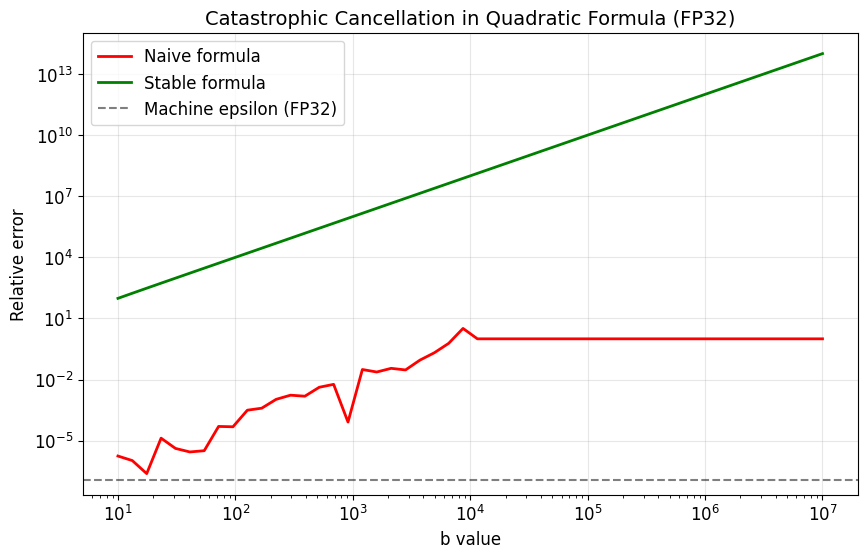

In [7]:
# Visualize relative error
b_range = np.logspace(1, 7, 50)
naive_errors = []
stable_errors = []

a, c = 1.0, 1.0

for b in b_range:
    # True value (using float64 as reference)
    true_small = c / (a * ((-b - np.sqrt(b**2 - 4*a*c)) / (2*a)))
    
    # Compute in float32
    naive_x1, _ = quadratic_naive(np.float32(a), np.float32(b), np.float32(c))
    stable_x1, _ = quadratic_stable(np.float32(a), np.float32(b), np.float32(c))
    
    naive_errors.append(abs(naive_x1 - true_small) / abs(true_small))
    stable_errors.append(abs(stable_x1 - true_small) / abs(true_small))

plt.figure(figsize=(10, 6))
plt.loglog(b_range, naive_errors, 'r-', linewidth=2, label='Naive formula')
plt.loglog(b_range, stable_errors, 'g-', linewidth=2, label='Stable formula')
plt.axhline(y=np.finfo(np.float32).eps, color='k', linestyle='--', 
            alpha=0.5, label='Machine epsilon (FP32)')
plt.xlabel('b value', fontsize=12)
plt.ylabel('Relative error', fontsize=12)
plt.title('Catastrophic Cancellation in Quadratic Formula (FP32)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 3. The Log-Sum-Exp Trick

The softmax function is central to classification:

$$\text{softmax}(x_i) = \frac{e^{x_i}}{\sum_j e^{x_j}}$$

**Problem**: For large $x_i$, $e^{x_i}$ overflows. For very negative $x_i$, $e^{x_i}$ underflows.

**Solution**: The log-sum-exp trick shifts values by the maximum:

$$\text{softmax}(x_i) = \frac{e^{x_i - \max(x)}}{\sum_j e^{x_j - \max(x)}}$$

In [8]:
def softmax_naive(x):
    """
    Naive softmax implementation.
    Prone to overflow for large values and underflow for very negative values.
    """
    exp_x = np.exp(x)
    return exp_x / np.sum(exp_x)

def softmax_stable(x):
    """
    Numerically stable softmax using the max-shift trick.
    """
    x_max = np.max(x)
    exp_x = np.exp(x - x_max)
    return exp_x / np.sum(exp_x)

def logsumexp_naive(x):
    """Naive log-sum-exp: log(sum(exp(x)))."""
    return np.log(np.sum(np.exp(x)))

def logsumexp_stable(x):
    """Stable log-sum-exp: max(x) + log(sum(exp(x - max(x))))."""
    x_max = np.max(x)
    return x_max + np.log(np.sum(np.exp(x - x_max)))

In [9]:
# Demonstrate overflow in naive softmax
print("=== Softmax Overflow Demonstration ===")

# Normal case
x_normal = np.array([1.0, 2.0, 3.0])
print(f"\nNormal input: {x_normal}")
print(f"Naive softmax:  {softmax_naive(x_normal)}")
print(f"Stable softmax: {softmax_stable(x_normal)}")

# Large values - causes overflow
x_large = np.array([1000.0, 1001.0, 1002.0])
print(f"\nLarge input: {x_large}")
print(f"Naive softmax:  {softmax_naive(x_large)}")
print(f"Stable softmax: {softmax_stable(x_large)}")

# Very negative values - causes underflow
x_negative = np.array([-1000.0, -999.0, -998.0])
print(f"\nVery negative input: {x_negative}")
print(f"Naive softmax:  {softmax_naive(x_negative)}")
print(f"Stable softmax: {softmax_stable(x_negative)}")

=== Softmax Overflow Demonstration ===

Normal input: [1. 2. 3.]
Naive softmax:  [0.09003057 0.24472847 0.66524096]
Stable softmax: [0.09003057 0.24472847 0.66524096]

Large input: [1000. 1001. 1002.]
Naive softmax:  [nan nan nan]
Stable softmax: [0.09003057 0.24472847 0.66524096]

Very negative input: [-1000.  -999.  -998.]
Naive softmax:  [nan nan nan]
Stable softmax: [0.09003057 0.24472847 0.66524096]


In [10]:
# Demonstrate log-sum-exp
print("=== Log-Sum-Exp Demonstration ===")

x_test = np.array([1000.0, 1000.5, 1001.0])
print(f"\nInput: {x_test}")
print(f"Naive logsumexp:  {logsumexp_naive(x_test)}")
print(f"Stable logsumexp: {logsumexp_stable(x_test)}")

# Compare with scipy
from scipy.special import logsumexp as scipy_logsumexp
print(f"Scipy logsumexp:  {scipy_logsumexp(x_test)}")

=== Log-Sum-Exp Demonstration ===

Input: [1000.  1000.5 1001. ]
Naive logsumexp:  inf
Stable logsumexp: 1001.6802696706417
Scipy logsumexp:  1001.6802696706417


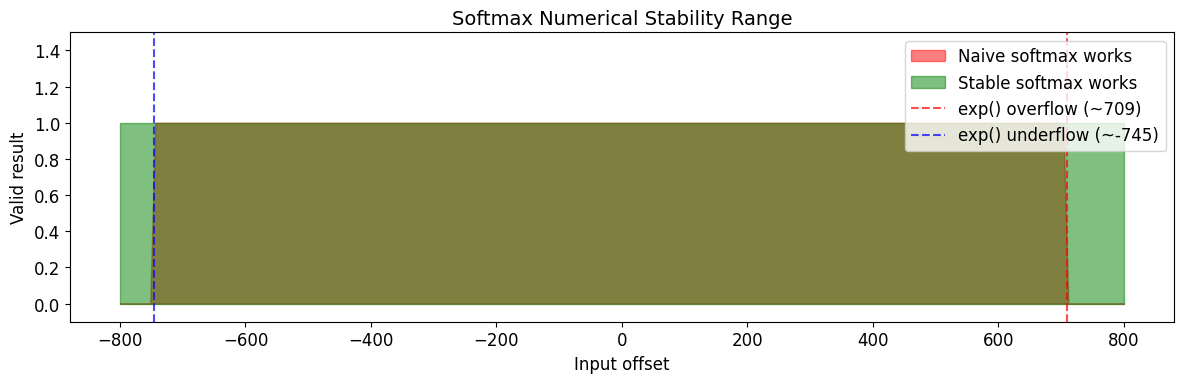

The stable softmax works for ANY input magnitude!


In [11]:
# Visualize where naive softmax fails
def test_softmax_range(offset_range):
    """Test softmax at different input magnitudes."""
    base = np.array([0.0, 0.5, 1.0])  # Simple 3-class logits
    
    naive_valid = []
    stable_valid = []
    
    for offset in offset_range:
        x = base + offset
        
        naive_result = softmax_naive(x)
        stable_result = softmax_stable(x)
        
        # Check if results are valid (no NaN/Inf and sum to 1)
        naive_ok = np.isfinite(naive_result).all() and abs(np.sum(naive_result) - 1.0) < 0.01
        stable_ok = np.isfinite(stable_result).all() and abs(np.sum(stable_result) - 1.0) < 0.01
        
        naive_valid.append(1 if naive_ok else 0)
        stable_valid.append(1 if stable_ok else 0)
    
    return naive_valid, stable_valid

offset_range = np.linspace(-800, 800, 200)
naive_valid, stable_valid = test_softmax_range(offset_range)

fig, ax = plt.subplots(figsize=(12, 4))
ax.fill_between(offset_range, 0, naive_valid, alpha=0.5, label='Naive softmax works', color='red')
ax.fill_between(offset_range, 0, stable_valid, alpha=0.5, label='Stable softmax works', color='green')

# Mark the overflow threshold for exp()
ax.axvline(x=709, color='red', linestyle='--', alpha=0.7, label='exp() overflow (~709)')
ax.axvline(x=-745, color='blue', linestyle='--', alpha=0.7, label='exp() underflow (~-745)')

ax.set_xlabel('Input offset', fontsize=12)
ax.set_ylabel('Valid result', fontsize=12)
ax.set_title('Softmax Numerical Stability Range', fontsize=14)
ax.legend(loc='upper right')
ax.set_ylim(-0.1, 1.5)
plt.tight_layout()
plt.show()

print("The stable softmax works for ANY input magnitude!")

## 4. Numerically Stable Cross-Entropy

Cross-entropy loss for classification:

$$L = -\sum_i y_i \log(p_i)$$

Where $p = \text{softmax}(z)$ are predicted probabilities.

**Problem**: Computing $\log(\text{softmax}(z))$ naively involves:
1. Computing softmax (can overflow)
2. Taking log of small probabilities (can underflow to -inf)

**Solution**: Combine into log-softmax:

$$\log(\text{softmax}(z_i)) = z_i - \text{logsumexp}(z)$$

In [12]:
def cross_entropy_naive(logits, labels):
    """
    Naive cross-entropy: compute softmax, then log, then loss.
    """
    probs = softmax_naive(logits)
    log_probs = np.log(probs)
    return -np.sum(labels * log_probs)

def cross_entropy_stable(logits, labels):
    """
    Numerically stable cross-entropy using log-softmax.
    
    log_softmax(x_i) = x_i - logsumexp(x)
    """
    log_sum_exp = logsumexp_stable(logits)
    log_probs = logits - log_sum_exp
    return -np.sum(labels * log_probs)

def cross_entropy_with_logits(logits, labels):
    """
    Most stable: combines softmax and cross-entropy.
    This is what PyTorch's CrossEntropyLoss does internally.
    """
    max_logit = np.max(logits)
    shifted = logits - max_logit
    log_sum_exp = max_logit + np.log(np.sum(np.exp(shifted)))
    return -np.sum(labels * logits) + log_sum_exp

In [13]:
# Demonstrate cross-entropy stability
print("=== Cross-Entropy Stability ===")

# One-hot label for class 2 (index 1)
labels = np.array([0, 1, 0])

# Normal case
logits_normal = np.array([1.0, 2.0, 0.5])
print(f"\nNormal logits: {logits_normal}")
print(f"  Naive CE:  {cross_entropy_naive(logits_normal, labels):.6f}")
print(f"  Stable CE: {cross_entropy_stable(logits_normal, labels):.6f}")

# Large positive logits
logits_large = np.array([1000.0, 1001.0, 999.5])
print(f"\nLarge logits: {logits_large}")
print(f"  Naive CE:  {cross_entropy_naive(logits_large, labels)}")
print(f"  Stable CE: {cross_entropy_stable(logits_large, labels):.6f}")

# Extreme confidence (one logit much larger)
logits_extreme = np.array([-100.0, 100.0, -100.0])  # Very confident in class 1
print(f"\nExtreme logits: {logits_extreme}")
print(f"  Naive CE:  {cross_entropy_naive(logits_extreme, labels)}")
print(f"  Stable CE: {cross_entropy_stable(logits_extreme, labels):.6f}")

=== Cross-Entropy Stability ===

Normal logits: [1.  2.  0.5]
  Naive CE:  0.464369
  Stable CE: 0.464369

Large logits: [1000.  1001.   999.5]
  Naive CE:  nan
  Stable CE: 0.464369

Extreme logits: [-100.  100. -100.]
  Naive CE:  -0.0
  Stable CE: -0.000000


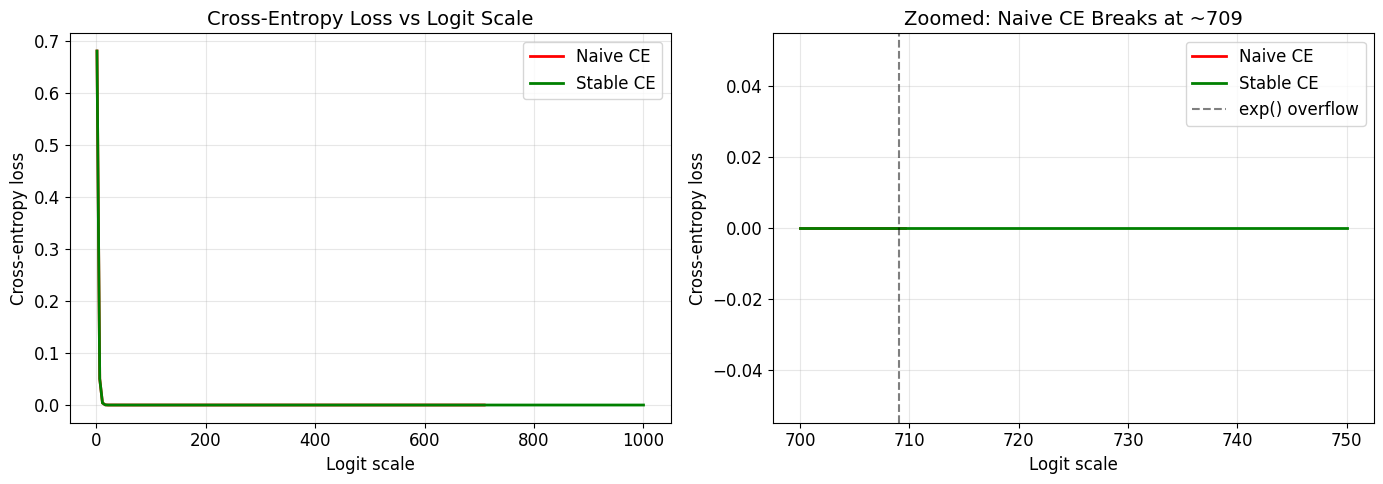

In [14]:
# Visualize where each method fails
def test_cross_entropy_stability(scale_range):
    """Test cross-entropy at different scales."""
    base_logits = np.array([0.0, 1.0, 0.5])  # Class 1 is correct
    labels = np.array([0, 1, 0])
    
    naive_losses = []
    stable_losses = []
    
    for scale in scale_range:
        logits = base_logits * scale
        
        naive_loss = cross_entropy_naive(logits, labels)
        stable_loss = cross_entropy_stable(logits, labels)
        
        naive_losses.append(naive_loss if np.isfinite(naive_loss) else np.nan)
        stable_losses.append(stable_loss if np.isfinite(stable_loss) else np.nan)
    
    return naive_losses, stable_losses

scale_range = np.linspace(1, 1000, 200)
naive_losses, stable_losses = test_cross_entropy_stability(scale_range)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss values
ax = axes[0]
ax.plot(scale_range, naive_losses, 'r-', linewidth=2, label='Naive CE')
ax.plot(scale_range, stable_losses, 'g-', linewidth=2, label='Stable CE')
ax.set_xlabel('Logit scale', fontsize=12)
ax.set_ylabel('Cross-entropy loss', fontsize=12)
ax.set_title('Cross-Entropy Loss vs Logit Scale', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

# Zoom in on where naive fails
ax = axes[1]
scale_zoom = np.linspace(700, 750, 100)
naive_zoom, stable_zoom = test_cross_entropy_stability(scale_zoom)

ax.plot(scale_zoom, naive_zoom, 'r-', linewidth=2, label='Naive CE')
ax.plot(scale_zoom, stable_zoom, 'g-', linewidth=2, label='Stable CE')
ax.axvline(x=709, color='k', linestyle='--', alpha=0.5, label='exp() overflow')
ax.set_xlabel('Logit scale', fontsize=12)
ax.set_ylabel('Cross-entropy loss', fontsize=12)
ax.set_title('Zoomed: Naive CE Breaks at ~709', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Gradient Checking

Gradient checking verifies backpropagation implementations by comparing analytical gradients with numerical approximations.

**Central difference approximation:**

$$\frac{\partial f}{\partial \theta_i} \approx \frac{f(\theta + \epsilon e_i) - f(\theta - \epsilon e_i)}{2\epsilon}$$

This has error $O(\epsilon^2)$, which is more accurate than forward/backward differences.

In [15]:
def numerical_gradient(f, x, epsilon=1e-5):
    """
    Compute numerical gradient using central differences.
    
    Parameters:
        f: Function that takes array and returns scalar
        x: Point at which to compute gradient
        epsilon: Step size for finite differences
    
    Returns:
        grad: Numerical gradient (same shape as x)
    """
    x = np.array(x, dtype=np.float64)
    grad = np.zeros_like(x)
    
    for i in range(len(x)):
        x_plus = x.copy()
        x_minus = x.copy()
        x_plus[i] += epsilon
        x_minus[i] -= epsilon
        
        grad[i] = (f(x_plus) - f(x_minus)) / (2 * epsilon)
    
    return grad

def gradient_check(f, grad_f, x, epsilon=1e-5):
    """
    Check if analytical gradient matches numerical gradient.
    
    Returns relative error.
    """
    numerical = numerical_gradient(f, x, epsilon)
    analytical = grad_f(x)
    
    # Relative error (with numerical stability for near-zero gradients)
    diff = np.linalg.norm(numerical - analytical)
    norm = np.linalg.norm(numerical) + np.linalg.norm(analytical)
    
    if norm == 0:
        return 0.0 if diff == 0 else float('inf')
    
    return diff / norm

In [16]:
# Test gradient checking on various functions
print("=== Gradient Checking Examples ===")

# 1. Simple quadratic
def f_quad(x):
    return np.sum(x**2)

def grad_quad(x):
    return 2*x

x = np.array([1.0, 2.0, 3.0])
error = gradient_check(f_quad, grad_quad, x)
print(f"\n1. Quadratic f(x) = sum(x^2)")
print(f"   x = {x}")
print(f"   Analytical gradient: {grad_quad(x)}")
print(f"   Numerical gradient:  {numerical_gradient(f_quad, x)}")
print(f"   Relative error: {error:.2e} {'(PASS)' if error < 1e-7 else '(FAIL)'}")

# 2. Cross-entropy loss
def ce_loss(logits):
    labels = np.array([0, 1, 0])
    return cross_entropy_stable(logits, labels)

def grad_ce(logits):
    """Gradient of cross-entropy is (softmax - labels)."""
    labels = np.array([0, 1, 0])
    return softmax_stable(logits) - labels

logits = np.array([1.0, 2.0, 0.5])
error = gradient_check(ce_loss, grad_ce, logits)
print(f"\n2. Cross-entropy loss")
print(f"   logits = {logits}")
print(f"   Analytical gradient: {grad_ce(logits)}")
print(f"   Numerical gradient:  {numerical_gradient(ce_loss, logits)}")
print(f"   Relative error: {error:.2e} {'(PASS)' if error < 1e-7 else '(FAIL)'}")

=== Gradient Checking Examples ===

1. Quadratic f(x) = sum(x^2)
   x = [1. 2. 3.]
   Analytical gradient: [2. 4. 6.]
   Numerical gradient:  [2. 4. 6.]
   Relative error: 7.51e-12 (PASS)

2. Cross-entropy loss
   logits = [1.  2.  0.5]
   Analytical gradient: [ 0.2312239  -0.37146828  0.14024438]
   Numerical gradient:  [ 0.2312239  -0.37146828  0.14024438]
   Relative error: 2.08e-11 (PASS)


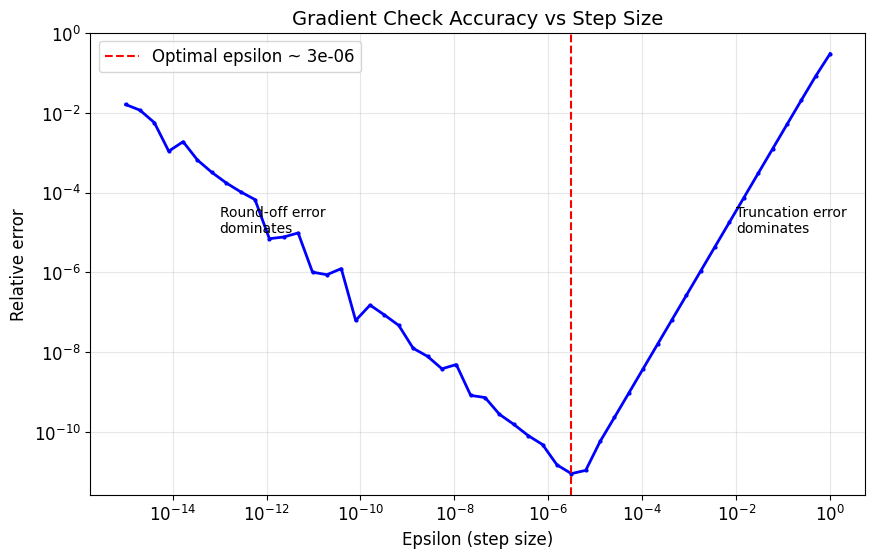

Optimal epsilon for gradient checking: ~3e-06
Rule of thumb: Use epsilon around 1e-5 to 1e-7


In [17]:
# Effect of epsilon on gradient checking accuracy
def test_function(x):
    """f(x) = sin(x[0]) * exp(-x[1]^2)"""
    return np.sin(x[0]) * np.exp(-x[1]**2)

def test_gradient(x):
    """Analytical gradient."""
    return np.array([
        np.cos(x[0]) * np.exp(-x[1]**2),
        -2 * x[1] * np.sin(x[0]) * np.exp(-x[1]**2)
    ])

x = np.array([1.0, 0.5])
epsilons = np.logspace(-15, 0, 50)
errors = []

for eps in epsilons:
    error = gradient_check(test_function, test_gradient, x, epsilon=eps)
    errors.append(error)

plt.figure(figsize=(10, 6))
plt.loglog(epsilons, errors, 'b.-', linewidth=2, markersize=4)
plt.xlabel('Epsilon (step size)', fontsize=12)
plt.ylabel('Relative error', fontsize=12)
plt.title('Gradient Check Accuracy vs Step Size', fontsize=14)

# Mark optimal region
optimal_eps = epsilons[np.argmin(errors)]
plt.axvline(x=optimal_eps, color='r', linestyle='--', 
            label=f'Optimal epsilon ~ {optimal_eps:.0e}')

# Annotate regions
plt.annotate('Truncation error\ndominates', xy=(1e-2, 1e-5), fontsize=10)
plt.annotate('Round-off error\ndominates', xy=(1e-13, 1e-5), fontsize=10)

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Optimal epsilon for gradient checking: ~{optimal_eps:.0e}")
print("Rule of thumb: Use epsilon around 1e-5 to 1e-7")

In [18]:
# Gradient checking for a simple neural network layer
def relu(x):
    return np.maximum(0, x)

def relu_grad(x):
    return (x > 0).astype(float)

def simple_layer_loss(params):
    """
    Simple layer: y = relu(Wx + b), loss = sum(y^2)
    params = [W.flatten(), b]
    """
    W = params[:6].reshape(2, 3)
    b = params[6:]
    x = np.array([1.0, 2.0, 3.0])  # Fixed input
    
    z = W @ x + b
    y = relu(z)
    loss = np.sum(y**2)
    return loss

def simple_layer_grad(params):
    """Analytical gradient via backprop."""
    W = params[:6].reshape(2, 3)
    b = params[6:]
    x = np.array([1.0, 2.0, 3.0])
    
    # Forward
    z = W @ x + b
    y = relu(z)
    
    # Backward
    dloss_dy = 2 * y
    dy_dz = relu_grad(z)
    dloss_dz = dloss_dy * dy_dz
    
    dloss_dW = np.outer(dloss_dz, x)
    dloss_db = dloss_dz
    
    return np.concatenate([dloss_dW.flatten(), dloss_db])

# Test
np.random.seed(42)
W_init = np.random.randn(2, 3) * 0.1
b_init = np.zeros(2)
params = np.concatenate([W_init.flatten(), b_init])

error = gradient_check(simple_layer_loss, simple_layer_grad, params)
print("=== Gradient Check for Simple Neural Network Layer ===")
print(f"Relative error: {error:.2e}")
print(f"Status: {'PASS' if error < 1e-5 else 'FAIL'}")

print("\nNumerical gradient:")
print(numerical_gradient(simple_layer_loss, params).round(6))
print("\nAnalytical gradient:")
print(simple_layer_grad(params).round(6))

=== Gradient Check for Simple Neural Network Layer ===
Relative error: 3.73e-13
Status: PASS

Numerical gradient:
[0.43265  0.8653   1.297951 0.070462 0.140925 0.211387 0.43265  0.070462]

Analytical gradient:
[0.43265  0.8653   1.297951 0.070462 0.140925 0.211387 0.43265  0.070462]


## 6. Mixed Precision Training

Modern GPUs support mixed precision training using FP16 (half precision) for speed while maintaining accuracy.

**Benefits of FP16:**
- 2x memory savings
- Faster computation on GPUs with Tensor Cores

**Challenges:**
- Reduced range (max ~65504 vs ~3.4e38 for FP32)
- Reduced precision (10 bits mantissa vs 23 bits)
- Gradients can underflow or weights can overflow

**Solutions:**
- Loss scaling to prevent gradient underflow
- Keep master weights in FP32

In [19]:
# Compare FP16 vs FP32 precision
print("=== FP16 vs FP32 Comparison ===")

# Precision comparison
print("\n1. Precision Limits:")
for dtype, name in [(np.float16, 'FP16'), (np.float32, 'FP32')]:
    info = np.finfo(dtype)
    print(f"   {name}: eps={info.eps:.2e}, max={info.max:.2e}, min_pos={info.tiny:.2e}")

# Demonstrate precision loss in accumulation
print("\n2. Accumulation Error:")
n = 10000
small_value = 0.0001

# FP16 accumulation
acc_16 = np.float16(0.0)
for _ in range(n):
    acc_16 = np.float16(acc_16 + np.float16(small_value))

# FP32 accumulation
acc_32 = np.float32(0.0)
for _ in range(n):
    acc_32 = np.float32(acc_32 + np.float32(small_value))

true_value = n * small_value
print(f"   True value: {true_value}")
print(f"   FP16 result: {acc_16} (error: {abs(acc_16 - true_value):.4f})")
print(f"   FP32 result: {acc_32} (error: {abs(acc_32 - true_value):.6f})")

=== FP16 vs FP32 Comparison ===

1. Precision Limits:
   FP16: eps=9.77e-04, max=6.55e+04, min_pos=6.10e-05
   FP32: eps=1.19e-07, max=3.40e+38, min_pos=1.18e-38

2. Accumulation Error:
   True value: 1.0
   FP16 result: 0.25 (error: 0.7500)
   FP32 result: 1.0000535249710083 (error: 0.000054)


In [20]:
# Demonstrate gradient underflow in FP16
print("=== Gradient Underflow in FP16 ===")

# Simulate small gradients that underflow in FP16
np.random.seed(42)
gradients_fp32 = np.random.randn(100) * 1e-5  # Small but non-zero gradients

# Convert to FP16
gradients_fp16 = gradients_fp32.astype(np.float16)

# Count zeros (underflowed values)
zeros_before = np.sum(gradients_fp32 == 0)
zeros_after = np.sum(gradients_fp16 == 0)

print(f"Original FP32 gradients: {zeros_before} zeros out of 100")
print(f"After FP16 conversion:   {zeros_after} zeros out of 100")
print(f"\nMany small gradients underflow to zero in FP16!")

# Show the minimum positive gradient in each format
print(f"\nSmallest non-zero |gradient| in FP32: {np.min(np.abs(gradients_fp32[gradients_fp32 != 0])):.2e}")
print(f"Smallest positive FP16 value: {np.finfo(np.float16).tiny:.2e}")

=== Gradient Underflow in FP16 ===
Original FP32 gradients: 0 zeros out of 100
After FP16 conversion:   0 zeros out of 100

Many small gradients underflow to zero in FP16!

Smallest non-zero |gradient| in FP32: 5.11e-08
Smallest positive FP16 value: 6.10e-05


In [21]:
# Loss scaling demonstration
def simulate_training_step(learning_rate, loss_scale=1.0, use_fp16=False):
    """
    Simulate one training step with optional loss scaling.
    """
    np.random.seed(42)
    
    # Simulate weights and gradients
    weights = np.random.randn(100).astype(np.float32)
    true_gradients = np.random.randn(100) * 1e-5  # Small gradients
    
    if use_fp16:
        # Without loss scaling: gradients underflow
        if loss_scale == 1.0:
            gradients = true_gradients.astype(np.float16)
        else:
            # With loss scaling: scale up, convert, compute, scale down
            scaled_grads = (true_gradients * loss_scale).astype(np.float16)
            gradients = (scaled_grads / loss_scale).astype(np.float32)
    else:
        gradients = true_gradients
    
    # Compute weight update
    weight_update = -learning_rate * gradients
    new_weights = weights + weight_update
    
    # Measure how much the weights actually changed
    actual_change = np.sum(np.abs(new_weights - weights))
    expected_change = learning_rate * np.sum(np.abs(true_gradients))
    
    return actual_change, expected_change

print("=== Loss Scaling Effect ===")
print("\nWith small gradients (1e-5 scale):")

lr = 0.01

actual, expected = simulate_training_step(lr, loss_scale=1.0, use_fp16=False)
print(f"  FP32:                 change={actual:.6f}, expected={expected:.6f}")

actual, expected = simulate_training_step(lr, loss_scale=1.0, use_fp16=True)
print(f"  FP16 (no scaling):    change={actual:.6f}, expected={expected:.6f}")

actual, expected = simulate_training_step(lr, loss_scale=1024.0, use_fp16=True)
print(f"  FP16 (scale=1024):    change={actual:.6f}, expected={expected:.6f}")

actual, expected = simulate_training_step(lr, loss_scale=65536.0, use_fp16=True)
print(f"  FP16 (scale=65536):   change={actual:.6f}, expected={expected:.6f}")

=== Loss Scaling Effect ===

With small gradients (1e-5 scale):
  FP32:                 change=0.000008, expected=0.000008
  FP16 (no scaling):    change=0.000007, expected=0.000008
  FP16 (scale=1024):    change=0.000007, expected=0.000008
  FP16 (scale=65536):   change=0.000000, expected=0.000008


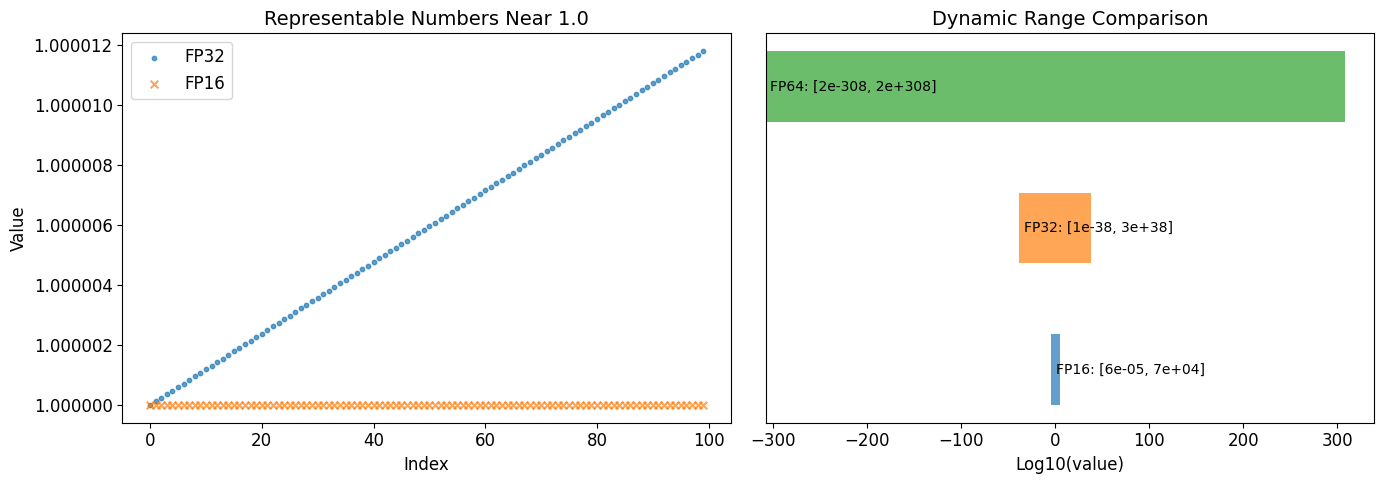

In [22]:
# Visualize FP16 vs FP32 representable numbers
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of representable numbers near 1
ax = axes[0]
x = 1.0
fp16_numbers = []
fp32_numbers = []

for _ in range(100):
    x_16 = np.float16(x)
    x_32 = np.float32(x)
    fp16_numbers.append(float(x_16))
    fp32_numbers.append(float(x_32))
    x = np.nextafter(x, np.inf, dtype=np.float32)

ax.scatter(range(100), fp32_numbers, s=10, label='FP32', alpha=0.7)
ax.scatter(range(100), [fp16_numbers[i] for i in range(100)], s=30, 
           marker='x', label='FP16', alpha=0.7)
ax.set_xlabel('Index', fontsize=12)
ax.set_ylabel('Value', fontsize=12)
ax.set_title('Representable Numbers Near 1.0', fontsize=14)
ax.legend()
ax.ticklabel_format(useOffset=False)

# Dynamic range comparison
ax = axes[1]
ranges = {
    'FP16': (np.finfo(np.float16).tiny, np.finfo(np.float16).max),
    'FP32': (np.finfo(np.float32).tiny, np.finfo(np.float32).max),
    'FP64': (np.finfo(np.float64).tiny, np.finfo(np.float64).max)
}

y_pos = [0, 1, 2]
for i, (name, (min_val, max_val)) in enumerate(ranges.items()):
    ax.barh(i, np.log10(max_val) - np.log10(min_val), left=np.log10(min_val),
            height=0.5, label=name, alpha=0.7)
    ax.text(np.log10(min_val) + 5, i, f'{name}: [{min_val:.0e}, {max_val:.0e}]',
            va='center', fontsize=10)

ax.set_xlabel('Log10(value)', fontsize=12)
ax.set_title('Dynamic Range Comparison', fontsize=14)
ax.set_yticks([])

plt.tight_layout()
plt.show()

## 7. Debugging NaN and Inf

NaN (Not a Number) and Inf (Infinity) are common failure modes in ML training.

**Common causes of NaN:**
1. Division by zero
2. Log of zero or negative numbers
3. Square root of negative numbers
4. 0/0 or inf - inf
5. Exploding gradients leading to inf, then inf * 0 = NaN

**Common causes of Inf:**
1. Overflow (numbers too large)
2. Division by very small numbers
3. Exp of large numbers
4. Exploding gradients

In [23]:
# Demonstrate common sources of NaN and Inf
print("=== Common Sources of NaN ===")

nan_sources = [
    ("0 / 0", lambda: np.float64(0) / np.float64(0)),
    ("inf - inf", lambda: np.inf - np.inf),
    ("inf * 0", lambda: np.inf * 0),
    ("sqrt(-1)", lambda: np.sqrt(-1)),
    ("log(0)", lambda: np.log(0)),  # Actually -inf
    ("log(-1)", lambda: np.log(-1)),
]

for name, func in nan_sources:
    result = func()
    print(f"{name:15} = {result}")

print("\n=== Common Sources of Inf ===")

inf_sources = [
    ("1 / 0", lambda: np.float64(1) / np.float64(0)),
    ("exp(1000)", lambda: np.exp(1000)),
    ("1e308 * 10", lambda: 1e308 * 10),
    ("-log(0)", lambda: -np.log(0)),
]

for name, func in inf_sources:
    result = func()
    print(f"{name:15} = {result}")

=== Common Sources of NaN ===
0 / 0           = nan
inf - inf       = nan
inf * 0         = nan
sqrt(-1)        = nan
log(0)          = -inf
log(-1)         = nan

=== Common Sources of Inf ===
1 / 0           = inf
exp(1000)       = inf
1e308 * 10      = inf
-log(0)         = inf


In [24]:
# Safe implementations of common operations
def safe_log(x, eps=1e-10):
    """Log with protection against zero/negative values."""
    return np.log(np.maximum(x, eps))

def safe_divide(a, b, eps=1e-10):
    """Division with protection against small denominators."""
    return a / np.maximum(np.abs(b), eps) * np.sign(b + eps)

def safe_exp(x, max_val=700):
    """Exp with protection against overflow."""
    return np.exp(np.minimum(x, max_val))

def safe_sqrt(x, eps=0):
    """Sqrt with protection against negative values."""
    return np.sqrt(np.maximum(x, eps))

print("=== Safe Operations ===")
print(f"log(0):       {np.log(0)}  ->  safe_log(0):      {safe_log(0)}")
print(f"1/0:          {1/np.float64(0)}  ->  safe_divide(1,0): {safe_divide(1, 0)}")
print(f"exp(1000):    {np.exp(1000)}  ->  safe_exp(1000):   {safe_exp(1000):.2e}")
print(f"sqrt(-1):     {np.sqrt(-1)}  ->  safe_sqrt(-1):    {safe_sqrt(-1)}")

=== Safe Operations ===
log(0):       -inf  ->  safe_log(0):      -23.025850929940457
1/0:          inf  ->  safe_divide(1,0): 10000000000.0
exp(1000):    inf  ->  safe_exp(1000):   1.01e+304
sqrt(-1):     nan  ->  safe_sqrt(-1):    0.0


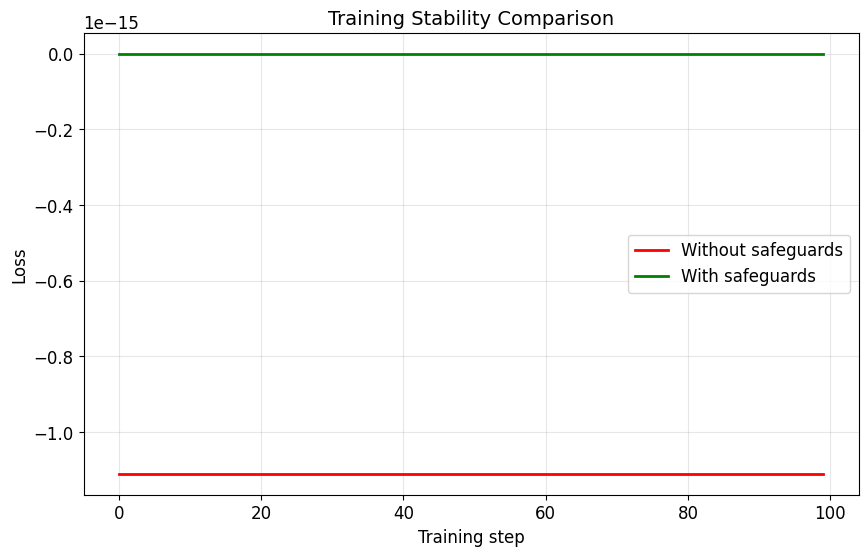

Without safeguards: 100 steps before failure
With safeguards: 100 steps completed


In [25]:
# Simulate training with and without safeguards
def simulate_unstable_training(n_steps=100, with_safeguards=False):
    """
    Simulate training that's prone to numerical issues.
    """
    np.random.seed(42)
    
    # Initialize
    weights = np.random.randn(10) * 0.1
    lr = 0.1
    losses = []
    
    for step in range(n_steps):
        # Simulate forward pass with potential issues
        x = np.random.randn(10)
        logits = weights @ x
        
        # Problematic softmax (logits can explode)
        if with_safeguards:
            probs = softmax_stable(logits.reshape(1, -1)).flatten()
        else:
            probs = softmax_naive(logits.reshape(1, -1)).flatten()
        
        # Cross-entropy loss (can have log(0))
        target = np.zeros(10)
        target[np.random.randint(10)] = 1
        
        if with_safeguards:
            loss = -np.sum(target * safe_log(probs))
        else:
            loss = -np.sum(target * np.log(probs + 1e-15))  # Minimal safeguard
        
        losses.append(loss)
        
        # Gradient (simplified)
        grad = (probs - target).reshape(-1, 1) @ x.reshape(1, -1)
        grad = grad.sum(axis=1)
        
        # Update with potential explosion
        weights = weights - lr * grad * (1 + 0.1 * step)  # Increasing gradient magnitude
        
        if not np.isfinite(loss):
            break
    
    return losses

# Run both versions
losses_unsafe = simulate_unstable_training(with_safeguards=False)
losses_safe = simulate_unstable_training(with_safeguards=True)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(losses_unsafe, 'r-', linewidth=2, label='Without safeguards')
ax.plot(losses_safe, 'g-', linewidth=2, label='With safeguards')
ax.set_xlabel('Training step', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('Training Stability Comparison', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

print(f"Without safeguards: {len(losses_unsafe)} steps before failure")
print(f"With safeguards: {len(losses_safe)} steps completed")

In [26]:
# Interactive debugging helper
def diagnose_tensor(x, name="tensor"):
    """
    Diagnose numerical issues in a tensor/array.
    """
    x = np.asarray(x)
    
    print(f"\n=== Diagnosis for '{name}' ===")
    print(f"Shape: {x.shape}")
    print(f"Dtype: {x.dtype}")
    
    # Check for special values
    n_nan = np.sum(np.isnan(x))
    n_inf = np.sum(np.isinf(x))
    n_zero = np.sum(x == 0)
    
    print(f"\nSpecial values:")
    print(f"  NaN count: {n_nan} ({100*n_nan/x.size:.1f}%)")
    print(f"  Inf count: {n_inf} ({100*n_inf/x.size:.1f}%)")
    print(f"  Zero count: {n_zero} ({100*n_zero/x.size:.1f}%)")
    
    # Statistics (excluding NaN/Inf)
    finite_x = x[np.isfinite(x)]
    if len(finite_x) > 0:
        print(f"\nStatistics (finite values only):")
        print(f"  Min: {np.min(finite_x):.6e}")
        print(f"  Max: {np.max(finite_x):.6e}")
        print(f"  Mean: {np.mean(finite_x):.6e}")
        print(f"  Std: {np.std(finite_x):.6e}")
        
        # Check for extreme values
        if np.max(np.abs(finite_x)) > 1e6:
            print("  WARNING: Contains very large values!")
        if np.min(np.abs(finite_x[finite_x != 0])) < 1e-10:
            print("  WARNING: Contains very small non-zero values!")
    else:
        print("\nNo finite values!")
    
    return n_nan > 0 or n_inf > 0

# Test the diagnostic function
np.random.seed(42)
test_array = np.random.randn(1000)
test_array[0] = np.nan
test_array[1] = np.inf
test_array[2] = -np.inf
test_array[3:10] = 0
test_array[10] = 1e10
test_array[11] = 1e-15

has_issues = diagnose_tensor(test_array, "test_gradients")


=== Diagnosis for 'test_gradients' ===
Shape: (1000,)
Dtype: float64

Special values:
  NaN count: 1 (0.1%)
  Inf count: 2 (0.2%)
  Zero count: 7 (0.7%)

Statistics (finite values only):
  Min: -3.241267e+00
  Max: 1.000000e+10
  Mean: 1.003009e+07
  Std: 3.165443e+08


## Summary: Debugging Checklist

When your ML model produces NaN or Inf, follow this systematic debugging checklist:

### Immediate Checks

1. **Check inputs**
   - Are there NaN/Inf values in your data?
   - Are features properly normalized?

2. **Check learning rate**
   - Is it too large causing gradient explosion?
   - Try reducing by 10x

3. **Check loss function**
   - Using log? Add small epsilon: `log(x + 1e-10)`
   - Using softmax + cross-entropy? Use combined stable version

### Architecture Checks

4. **Check weight initialization**
   - Too large can cause explosion
   - Use appropriate initialization (Xavier, He)

5. **Check for division operations**
   - Batch norm: `x / (std + eps)`
   - Layer norm: same pattern
   - Attention: `softmax(QK^T / sqrt(d))`

6. **Check activation functions**
   - Exp in attention can overflow
   - Use stable softmax

### Training Checks

7. **Gradient clipping**
   - Add gradient clipping: `clip_grad_norm_(parameters, max_norm=1.0)`

8. **Mixed precision**
   - If using FP16, enable loss scaling
   - Check for gradient underflow

9. **Batch size**
   - Very small batches can have unstable statistics

### Code for Detection

```python
# Add to training loop for debugging
def check_for_nan(tensor, name):
    if torch.isnan(tensor).any():
        raise ValueError(f"NaN detected in {name}")
    if torch.isinf(tensor).any():
        raise ValueError(f"Inf detected in {name}")

# Check at key points
check_for_nan(loss, "loss")
check_for_nan(logits, "logits") 
for name, param in model.named_parameters():
    check_for_nan(param.grad, f"{name}.grad")
```

---

### Key Takeaways

1. **Always use numerically stable implementations** - softmax, cross-entropy, log-sum-exp
2. **Gradient checking** validates your backprop - use epsilon around 1e-5 to 1e-7
3. **Mixed precision** requires loss scaling to prevent gradient underflow
4. **When debugging NaN** - work backwards from where it first appears
5. **Add safeguards proactively** - epsilon in denominators, clamp log inputs

---

*Continue to Chapter 9 for Probability and Statistics...*